# Phase II Data Quality Analysis

This notebook evaluates the quality and structure of the balanced Google Play Store and Apple App Store review datasets before deeper exploratory data analysis.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Find project root whether the notebook runs from the root
# or from the notebooks folder
ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

APPLE_PATH = ROOT / "data" / "processed" / "apple_store_analysis.csv"
GOOGLE_PATH = ROOT / "data" / "processed" / "google_play_analysis.csv"

apple = pd.read_csv(APPLE_PATH)
google = pd.read_csv(GOOGLE_PATH)

print("Apple rows:", len(apple))
print("Google rows:", len(google))

Apple rows: 13599
Google rows: 13599


## 1. Dataset Overview

In [3]:
print("Apple dataset shape:")
print(apple.shape)

print("\nGoogle Play dataset shape:")
print(google.shape)

print("\nApple columns:")
print(apple.columns.tolist())

print("\nGoogle Play columns:")
print(google.columns.tolist())

Apple dataset shape:
(13599, 14)

Google Play dataset shape:
(13599, 15)

Apple columns:
['platform', 'app_name', 'app_id', 'category', 'review_id', 'review_title', 'review_text', 'rating', 'review_date', 'app_version', 'reviewer_name', 'helpful_count', 'source_page', 'collection_timestamp']

Google Play columns:
['platform', 'app_name', 'app_id', 'category', 'review_id', 'review_text', 'rating', 'review_date', 'app_version', 'developer_response', 'developer_response_date', 'reviewer_name', 'helpful_count', 'source_batch', 'collection_timestamp']


## 2. Missing Values

In [4]:
apple_missing = pd.DataFrame({
    "missing_count": apple.isnull().sum(),
    "missing_percent": (apple.isnull().mean() * 100).round(2)
})

google_missing = pd.DataFrame({
    "missing_count": google.isnull().sum(),
    "missing_percent": (google.isnull().mean() * 100).round(2)
})

print("Apple Missing Values:")
display(apple_missing)

print("\nGoogle Play Missing Values:")
display(google_missing)

Apple Missing Values:


,missing_count,missing_percent
platform,0,0.00
app_name,0,0.00
app_id,0,0.00
category,0,0.00
review_id,0,0.00
review_title,2,0.01
review_text,1,0.01
rating,0,0.00
review_date,0,0.00
app_version,0,0.00



Google Play Missing Values:


,missing_count,missing_percent
platform,0,0.00
app_name,0,0.00
app_id,0,0.00
category,0,0.00
review_id,0,0.00
review_text,1,0.01
rating,0,0.00
review_date,0,0.00
app_version,2190,16.10
developer_response,10895,80.12


### Initial Findings

- Apple App Store data is almost complete across the observed fields. Only 1 review text and 2 review titles are missing out of 13,599 reviews.
- Google Play core fields such as review ID, rating, review date, and reviewer name are highly complete.
- Google Play app-version metadata is less complete, with 2,190 missing values (16.10%).
- Developer responses are much sparser on Google Play: 10,895 reviews (80.12%) do not contain a developer response.
- The two platforms therefore differ meaningfully in metadata availability, which should be considered when designing downstream analyses.

## 3. Duplicate and Repeated Review Checks

In [5]:
duplicate_summary = pd.DataFrame({
    "metric": [
        "Duplicate review IDs",
        "Repeated review text"
    ],
    "Apple App Store": [
        apple["review_id"].duplicated().sum(),
        apple["review_text"].duplicated().sum()
    ],
    "Google Play Store": [
        google["review_id"].duplicated().sum(),
        google["review_text"].duplicated().sum()
    ]
})

display(duplicate_summary)

,metric,Apple App Store,Google Play Store
0,Duplicate review IDs,0,0
1,Repeated review text,454,2319


In [6]:
apple_repeated_pct = (
    apple["review_text"].duplicated().mean() * 100
)

google_repeated_pct = (
    google["review_text"].duplicated().mean() * 100
)

print(
    f"Apple repeated-text rate: "
    f"{apple_repeated_pct:.2f}%"
)

print(
    f"Google Play repeated-text rate: "
    f"{google_repeated_pct:.2f}%"
)

Apple repeated-text rate: 3.34%
Google Play repeated-text rate: 17.05%


### Initial Findings

- No duplicate review IDs remain in either processed dataset.
- Repeated review text is substantially more common on Google Play Store than on Apple App Store.
- Approximately 17.05% of Google Play reviews repeat text that appears elsewhere in the dataset, compared with 3.34% on Apple App Store.
- Repeated text does not necessarily indicate duplicate records, since different users may independently submit short comments such as "Good", "Great", or "Love it".
- Repeated review text will therefore be retained for the main EDA and examined further as a data-quality characteristic rather than automatically removed.

## 4. Rating Distribution

In [10]:
apple_rating = (
    apple["rating"]
    .value_counts()
    .sort_index()
)

google_rating = (
    google["rating"]
    .value_counts()
    .sort_index()
)

rating_summary = pd.DataFrame({
    "Apple App Store": apple_rating,
    "Google Play Store": google_rating
})

display(rating_summary)

,Apple App Store,Google Play Store
rating,,
1,4728,3252
2,955,664
3,923,712
4,859,1114
5,6134,7857


In [11]:
rating_percent = (
    rating_summary
    .div(rating_summary.sum(axis=0), axis=1)
    * 100
).round(2)

display(rating_percent)

,Apple App Store,Google Play Store
rating,,
1,34.77,23.91
2,7.02,4.88
3,6.79,5.24
4,6.32,8.19
5,45.11,57.78


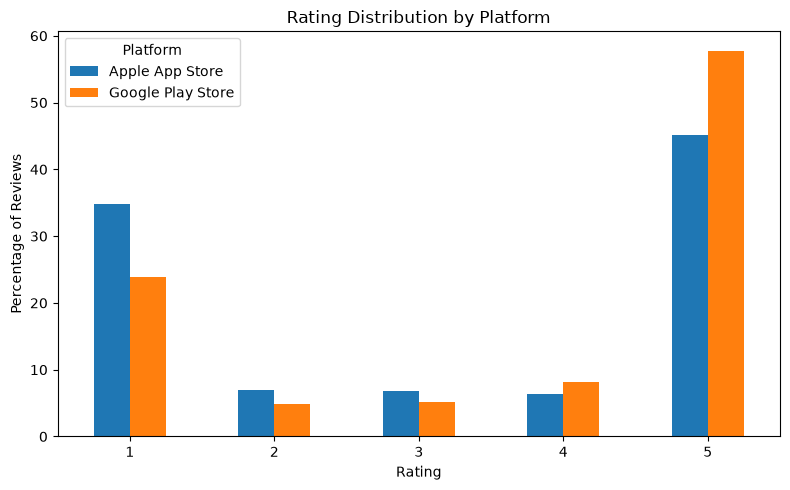

In [12]:
rating_percent.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Rating Distribution by Platform")
plt.xlabel("Rating")
plt.ylabel("Percentage of Reviews")
plt.xticks(rotation=0)
plt.legend(title="Platform")
plt.tight_layout()
plt.show()

### Initial Findings

- Rating distributions are polarized on both platforms, with 1-star and 5-star reviews accounting for most observations.
- Google Play has a substantially higher share of 5-star reviews (57.78%) than Apple App Store (45.11%).
- Apple App Store has a higher share of 1-star reviews (34.77%) than Google Play (23.91%).
- Mid-range ratings from 2 to 4 stars are relatively uncommon on both platforms.
- These aggregate differences suggest potentially different rating behavior across platforms, but app-level and time-window differences should be examined before interpreting them as platform effects.

In [13]:
apple_app_rating = (
    apple.groupby("app_name")["rating"]
    .mean()
    .rename("Apple App Store")
)

google_app_rating = (
    google.groupby("app_name")["rating"]
    .mean()
    .rename("Google Play Store")
)

app_rating_comparison = pd.concat(
    [apple_app_rating, google_app_rating],
    axis=1
)

app_rating_comparison["Difference"] = (
    app_rating_comparison["Google Play Store"]
    - app_rating_comparison["Apple App Store"]
)

app_rating_comparison = (
    app_rating_comparison
    .sort_values("Difference")
)

display(
    app_rating_comparison.round(2)
)

,Apple App Store,Google Play Store,Difference
app_name,,,
Pandora,4.28,3.31,-0.98
Lyft,4.08,3.23,-0.85
Spotify,3.91,3.60,-0.31
Coursera,3.09,2.82,-0.27
Uber,3.99,3.87,-0.12
SoundCloud,4.33,4.23,-0.10
Khan Academy,3.96,3.92,-0.04
Google Drive,3.86,3.95,0.08
Dropbox,3.35,3.46,0.11


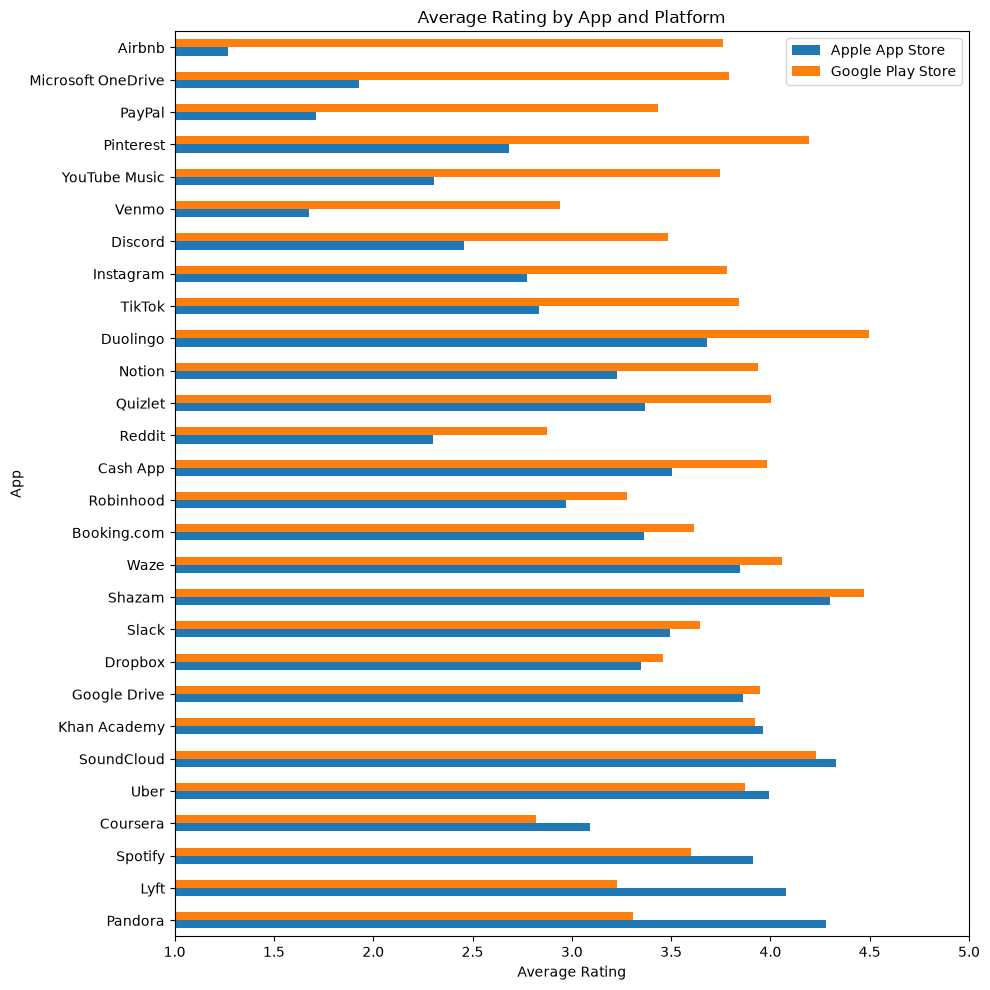

In [14]:
app_rating_comparison[
    ["Apple App Store", "Google Play Store"]
].plot(
    kind="barh",
    figsize=(10, 10)
)

plt.title("Average Rating by App and Platform")
plt.xlabel("Average Rating")
plt.ylabel("App")
plt.xlim(1, 5)
plt.tight_layout()
plt.show()

### App-Level Findings

- Average ratings vary substantially across both applications and platforms.
- Several apps show much higher average ratings on Google Play than on Apple App Store. The largest observed gaps include Airbnb, Microsoft OneDrive, PayPal, Pinterest, and YouTube Music.
- However, the direction of the platform difference is not consistent across all apps. Pandora and Lyft, for example, have noticeably higher average ratings on Apple App Store.
- Reddit has relatively low average ratings on both platforms, suggesting that some negative-review patterns may be app-specific rather than purely platform-specific.
- These results indicate that aggregate platform-level rating differences are partly driven by individual applications and should not be interpreted as a uniform platform effect.
- Differences in timestamp coverage between the two platforms may also contribute to some of the observed gaps and will be examined separately.

## 5. Review Length and Low-Information Comments

In [15]:
apple["review_length"] = (
    apple["review_text"]
    .fillna("")
    .str.len()
)

google["review_length"] = (
    google["review_text"]
    .fillna("")
    .str.len()
)

length_summary = pd.DataFrame({
    "Apple App Store": apple["review_length"].describe(),
    "Google Play Store": google["review_length"].describe()
})

display(length_summary.round(2))

,Apple App Store,Google Play Store
count,13599.00,13599.00
mean,175.07,90.31
std,234.99,118.74
min,0.00,0.00
25%,40.00,12.00
50%,103.00,38.00
75%,220.00,117.00
max,5980.00,500.00


### Initial Findings

- Apple App Store reviews are substantially longer than Google Play reviews in the matched sample.
- The median review length is 103 characters on Apple App Store compared with 38 characters on Google Play.
- Mean review length is also higher on Apple App Store (175.07 vs. 90.31 characters).
- Review-length distributions are right-skewed on both platforms, as the mean is noticeably higher than the median.
- Short reviews appear to be more common on Google Play, which may help explain the higher repeated-text rate observed earlier.
- The maximum Google Play review length in the collected data is 500 characters, so source or collection-method constraints should be considered before interpreting extreme-length differences as purely user behavior.

In [16]:
low_info_summary = pd.DataFrame({
    "Apple App Store": [
        (apple["review_length"] <= 10).sum(),
        (apple["review_length"] <= 20).sum()
    ],
    "Google Play Store": [
        (google["review_length"] <= 10).sum(),
        (google["review_length"] <= 20).sum()
    ]
}, index=[
    "10 characters or fewer",
    "20 characters or fewer"
])

display(low_info_summary)

,Apple App Store,Google Play Store
10 characters or fewer,987,3001
20 characters or fewer,1972,4920


In [17]:
low_info_percent = pd.DataFrame({
    "Apple App Store": [
        (apple["review_length"] <= 10).mean() * 100,
        (apple["review_length"] <= 20).mean() * 100
    ],
    "Google Play Store": [
        (google["review_length"] <= 10).mean() * 100,
        (google["review_length"] <= 20).mean() * 100
    ]
}, index=[
    "10 characters or fewer",
    "20 characters or fewer"
]).round(2)

display(low_info_percent)

,Apple App Store,Google Play Store
10 characters or fewer,7.26,22.07
20 characters or fewer,14.50,36.18


### Low-Information Comment Findings

- Short, potentially low-information reviews are much more common on Google Play than on Apple App Store.
- Reviews of 10 characters or fewer account for 22.07% of Google Play reviews, compared with 7.26% on Apple App Store.
- Using a 20-character threshold, 36.18% of Google Play reviews are very short, compared with 14.50% on Apple App Store.
- This pattern is consistent with the higher repeated-text rate observed on Google Play and suggests that text richness differs meaningfully across platforms.
- These thresholds are used as simple exploratory indicators of low-information content rather than definitive quality labels.

### Review Length by Rating

In [18]:
apple_length_by_rating = (
    apple.groupby("rating")["review_length"]
    .agg(["count", "mean", "median"])
    .round(2)
)

google_length_by_rating = (
    google.groupby("rating")["review_length"]
    .agg(["count", "mean", "median"])
    .round(2)
)

print("Apple App Store:")
display(apple_length_by_rating)

print("\nGoogle Play Store:")
display(google_length_by_rating)

Apple App Store:


,count,mean,median
rating,,,
1,4728,243.26,161.0
2,955,266.95,192.0
3,923,233.42,167.0
4,859,191.39,123.0
5,6134,97.15,54.0



Google Play Store:


,count,mean,median
rating,,,
1,3252,166.28,116.5
2,664,171.53,134.0
3,712,125.13,81.0
4,1114,84.73,40.0
5,7857,49.64,20.0


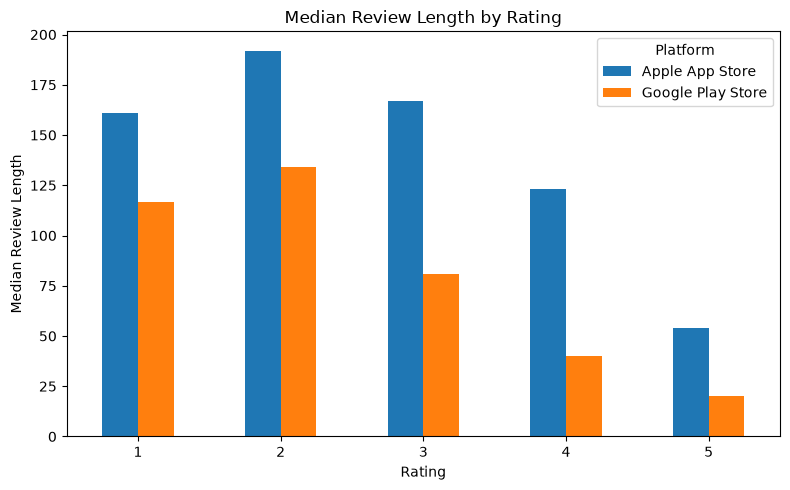

In [19]:
median_length_by_rating = pd.DataFrame({
    "Apple App Store": (
        apple.groupby("rating")["review_length"]
        .median()
    ),
    "Google Play Store": (
        google.groupby("rating")["review_length"]
        .median()
    )
})

median_length_by_rating.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Median Review Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Median Review Length")
plt.xticks(rotation=0)
plt.legend(title="Platform")
plt.tight_layout()
plt.show()

### Review Length by Rating Findings

- Review length varies substantially by rating on both platforms.
- Lower-rated reviews generally contain more text than higher-rated reviews, although the relationship is not strictly monotonic.
- On Apple App Store, the median review length is 161 characters for 1-star reviews and 192 characters for 2-star reviews, compared with only 54 characters for 5-star reviews.
- On Google Play, the corresponding medians are 116.5 characters for 1-star reviews, 134 characters for 2-star reviews, and only 20 characters for 5-star reviews.
- Two-star reviews have the longest median review length on both platforms, suggesting that dissatisfied users who provide somewhat more nuanced ratings may also provide more detailed explanations.
- Apple reviews remain longer than Google Play reviews at every rating level in the matched sample.
- Overall, the results support a relationship between lower ratings and greater review detail, but the pattern should not be interpreted as a strictly linear relationship.

## 6. Timestamp Coverage

In [23]:
apple["review_date"] = pd.to_datetime(
    apple["review_date"],
    errors="coerce",
    utc=True
)

google["review_date"] = pd.to_datetime(
    google["review_date"],
    errors="coerce",
    utc=True
)

apple_date_coverage = (
    apple.groupby("app_name")["review_date"]
    .agg(["min", "max"])
)

google_date_coverage = (
    google.groupby("app_name")["review_date"]
    .agg(["min", "max"])
)

apple_date_coverage["coverage_days"] = (
    apple_date_coverage["max"]
    - apple_date_coverage["min"]
).dt.total_seconds() / 86400

google_date_coverage["coverage_days"] = (
    google_date_coverage["max"]
    - google_date_coverage["min"]
).dt.total_seconds() / 86400

date_comparison = pd.DataFrame({
    "Apple Days": apple_date_coverage["coverage_days"],
    "Google Play Days": google_date_coverage["coverage_days"]
}).round(2)

display(date_comparison)

,Apple Days,Google Play Days
app_name,,
Airbnb,117.80,12.08
Booking.com,33.75,9.91
Cash App,17.72,5.03
Coursera,875.63,242.12
Discord,9.68,3.19
Dropbox,204.53,76.72
Duolingo,2.86,0.33
Google Drive,65.22,11.32
Instagram,4.95,0.24


### Timestamp Coverage Findings

- Equal review counts do not represent equal historical coverage across platforms.
- For many applications, Apple App Store reviews span a substantially longer time period than the matched Google Play sample.
- Large differences are especially visible for apps such as Microsoft OneDrive, Airbnb, YouTube Music, Notion, and Google Drive.
- Some exceptions exist. For example, the Google Play samples for Lyft and Pandora cover longer time periods than their Apple App Store counterparts.
- These results suggest substantial differences in review arrival rates and/or accessible review history across apps and platforms.
- Because the review time windows are not matched, aggregate and app-level rating differences should not automatically be interpreted as pure platform effects.

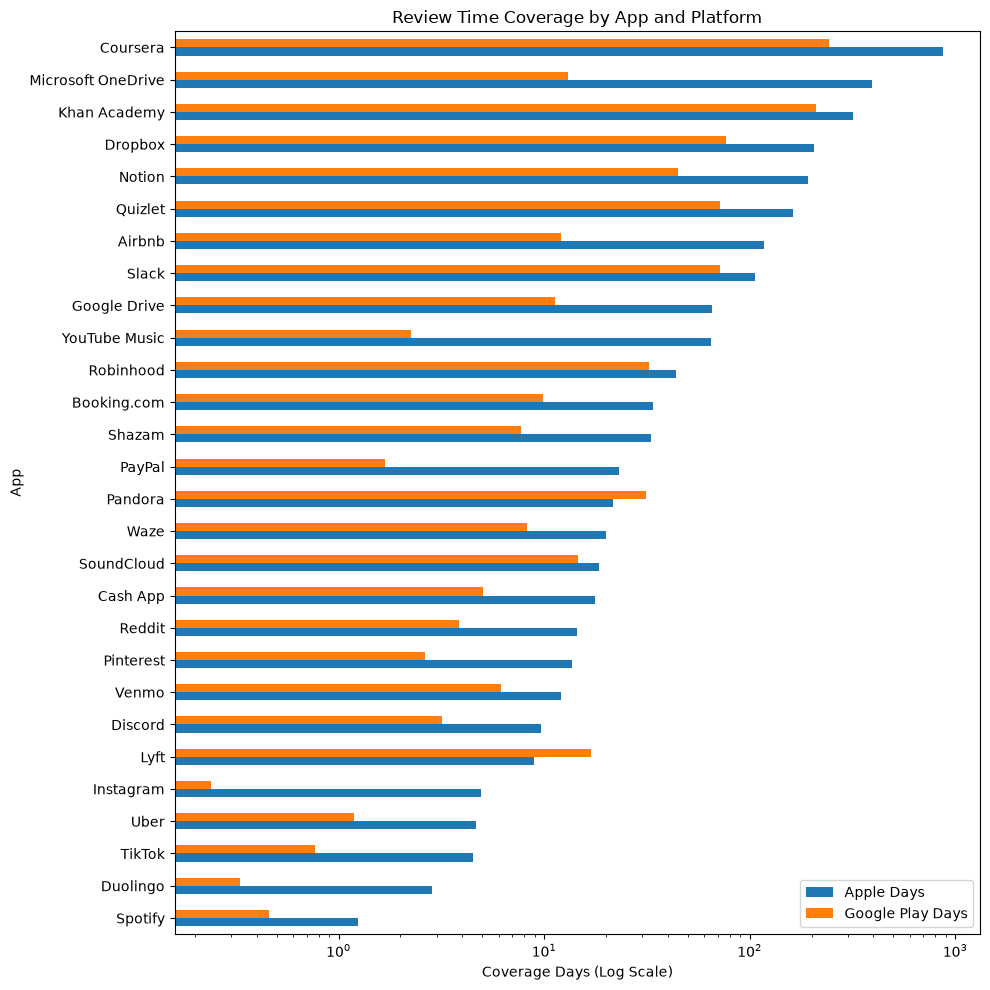

In [24]:
date_comparison.sort_values(
    "Apple Days"
).plot(
    kind="barh",
    figsize=(10, 10)
)

plt.title("Review Time Coverage by App and Platform")
plt.xlabel("Coverage Days (Log Scale)")
plt.ylabel("App")
plt.xscale("log")
plt.tight_layout()
plt.show()

In [25]:
date_comparison["Apple_to_Google_Ratio"] = (
    date_comparison["Apple Days"]
    / date_comparison["Google Play Days"]
)

display(
    date_comparison
    .sort_values(
        "Apple_to_Google_Ratio",
        ascending=False
    )
    .round(2)
)

,Apple Days,Google Play Days,Apple_to_Google_Ratio
app_name,,,
Microsoft OneDrive,395.01,13.10,30.15
YouTube Music,65.09,2.26,28.80
Instagram,4.95,0.24,20.62
PayPal,23.11,1.69,13.67
Airbnb,117.80,12.08,9.75
Duolingo,2.86,0.33,8.67
TikTok,4.49,0.77,5.83
Google Drive,65.22,11.32,5.76
Pinterest,13.63,2.63,5.18


### Timestamp Coverage Findings

- Matching the number of reviews does not guarantee comparable historical coverage across platforms.
- For many apps, the Apple App Store sample spans a substantially longer time period than the matched Google Play sample.
- The largest observed coverage gaps include Microsoft OneDrive, YouTube Music, Instagram, PayPal, and Airbnb.
- For example, the Apple sample for Microsoft OneDrive covers about 30 times the number of days represented by the matched Google Play sample.
- However, the pattern is not universal: Google Play covers a longer time period for some apps such as Pandora and Lyft.
- These differences suggest that review arrival rates and accessible review history vary substantially across apps and platforms.
- Because time windows are not matched, observed rating differences should not automatically be interpreted as pure platform effects.

## 7. Metadata Availability

In [26]:
metadata_summary = pd.DataFrame({
    "Apple App Store": [
        apple["app_version"].notna().mean() * 100,
        None,
        None
    ],
    "Google Play Store": [
        google["app_version"].notna().mean() * 100,
        google["developer_response"].notna().mean() * 100,
        google["developer_response_date"].notna().mean() * 100
    ]
}, index=[
    "App version available (%)",
    "Developer response available (%)",
    "Developer response date available (%)"
]).round(2)

display(metadata_summary)

,Apple App Store,Google Play Store
App version available (%),100.0,83.90
Developer response available (%),NaN,19.88
Developer response date available (%),NaN,19.88


### Metadata Availability Findings

- App-version metadata is available for 100% of the Apple App Store reviews in the processed dataset, compared with 83.90% of Google Play reviews.
- Developer-response metadata is available for only 19.88% of Google Play reviews.
- Developer-response and developer-response-date fields were not available through the Apple App Store collection method used in this project.
- This confirms that metadata availability differs meaningfully across platforms and that downstream analyses should rely only on fields that are consistently available within each source.
- Cross-platform comparisons involving developer responses are therefore not appropriate with the current datasets.